In [1]:
import pandas as pd 

df = pd.read_csv('../synthetic_data/synthetic_example.csv')

In [2]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit
0,Medina-Armstrong,Couple Landing – DarkOrchid,28/08/2023,Complete,Heather Cervantes,Design Issues,Normal,Visual bug in the footer needs fixing. This sh...,Mobile,Firefox,https://www.couplelanding–darkorchid.com,3,4,3.00
1,"Cox, Miller and Marquez",Final Dashboard – MediumSlateBlue,14/08/2023,Complete,Whitney Bell,Requested Change,Normal,"Hey team, this is Whitney Bell from Cox, Mille...",Mobile,Safari,https://www.finaldashboard–mediumslateblue.com,2,3,4.55
2,"Carter, Alvarado and Acosta",Hotel Landing – Wheat,31/12/2019,Complete,Christine Myers,Copy Revision,Low,Copy update needed for section 'about us page'.!,Mobile,Safari,https://www.hotellanding–wheat.com,1,2,3.15
3,Cruz-Mcguire,Popular Redesign – DarkOrange,18/04/2022,Complete,Joseph Schmidt,Design Issues,Urgent,Quick note from Joseph Schmidt (Cruz-Mcguire)....,Desktop,Chrome,https://www.popularredesign–darkorange.com,8,10,3.90
4,Odonnell-Hernandez,Director Redesign – Beige,20/10/2022,Complete,Derrick Rivera,Requested Change,High,Heads up! Derrick Rivera from Odonnell-Hernand...,Mobile,Chrome,https://www.directorredesign–beige.com,3,2,3.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Stephens-Sanders,Ahead Platform – DarkGray,13/12/2020,Complete,Megan Herrera DVM,Requested Change,High,Quick note from Megan Herrera DVM (Stephens-Sa...,Desktop,Safari,https://www.aheadplatform–darkgray.com,5,3,4.15
9996,"Carter, Alvarado and Acosta",Control Redesign – SlateBlue,04/07/2024,Complete,Brandon Garza,Copy Revision,Low,"Brandon Garza, Carter, Alvarado and Acosta – s...",Mobile,Firefox,https://www.controlredesign–slateblue.com,13,14,3.15
9997,Hawkins Inc,Choose Redesign – DarkBlue,20/06/2020,Complete,Pamela Carter,New Item,Normal,"Hey team, this is Pamela Carter from Hawkins I...",Desktop,Chrome,https://www.chooseredesign–darkblue.com,13,19,3.60
9998,Baker-White,Per Redesign – Peru,20/04/2022,Complete,Jennifer Nelson,Copy Revision,Low,Noticed something odd in area: contact form. C...,Desktop,Chrome,https://www.perredesign–peru.com,1,2,4.70


In [23]:
df.describe()

,Estimated Time (tokens),Real Time,ClientStrategicFit,Predicted Type,Predicted Real Time
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.657700,4.796500,3.709590,1.486300,4.796500
std,3.527914,3.928159,0.765766,1.121043,1.764389
min,1.000000,0.000000,1.800000,0.000000,-0.143800
25%,2.000000,2.000000,3.150000,0.000000,3.417166
50%,3.000000,4.000000,3.850000,1.000000,4.779324
75%,5.000000,6.000000,4.200000,2.000000,6.072084
max,13.000000,35.000000,4.700000,3.000000,12.289144


In [24]:
df = pd.read_csv("../synthetic_data/synthetic_example.csv")

# EDA general del DataFrame
eda_summary = {
    "Dimensiones": df.shape,
    "Columnas": df.columns.tolist(),
    "Tipos de datos": df.dtypes,
    "Valores nulos por columna": df.isnull().sum(),
    "Valores únicos por columna": df.nunique(),
    "Estadísticas numéricas": df.describe(include=[float, int]),
    "Estadísticas categóricas": df.describe(include=[object])
}

eda_summary


{'Dimensiones': (10000, 14),
 'Columnas': ['Company',
  'Project Name',
  'Input Date',
  'Status',
  'Requester',
  'Request Type',
  'Priority',
  'Request',
  'Device',
  'Browser',
  'Page',
  'Estimated Time (tokens)',
  'Real Time',
  'ClientStrategicFit'],
 'Tipos de datos': Company                     object
 Project Name                object
 Input Date                  object
 Status                      object
 Requester                   object
 Request Type                object
 Priority                    object
 Request                     object
 Device                      object
 Browser                     object
 Page                        object
 Estimated Time (tokens)      int64
 Real Time                    int64
 ClientStrategicFit         float64
 dtype: object,
 'Valores nulos por columna': Company                    0
 Project Name               0
 Input Date                 0
 Status                     0
 Requester                  0
 Request Type      

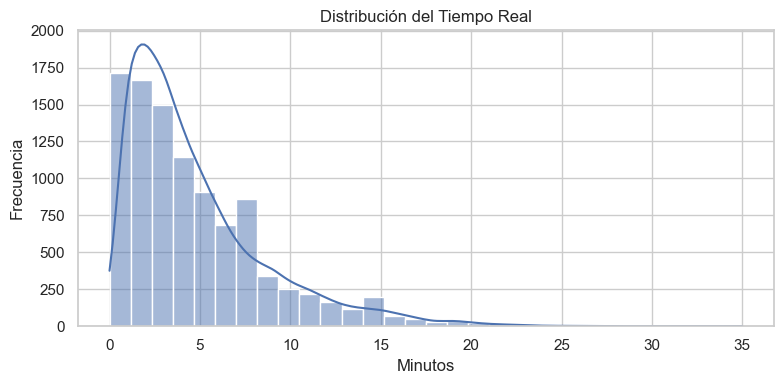

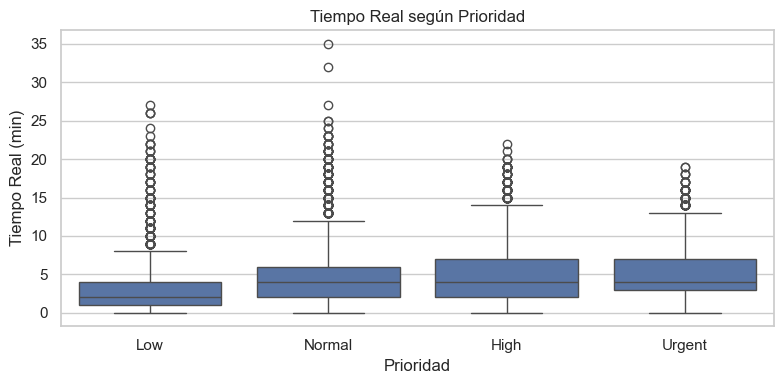

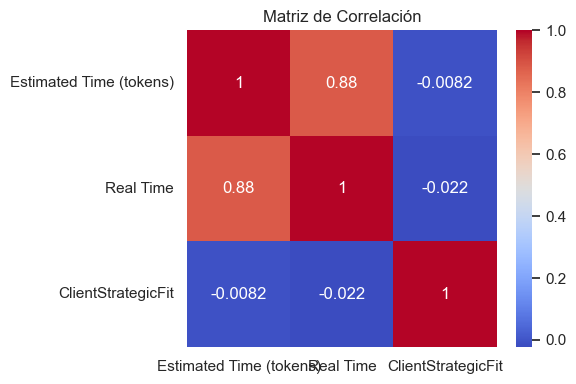

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")

# Distribución del tiempo real
plt.figure(figsize=(8, 4))
sns.histplot(df["Real Time"], bins=30, kde=True)
plt.title("Distribución del Tiempo Real")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot del tiempo real por prioridad
plt.figure(figsize=(8, 4))
sns.boxplot(x="Priority", y="Real Time", data=df, order=["Low", "Normal", "High", "Urgent"])
plt.title("Tiempo Real según Prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Tiempo Real (min)")
plt.tight_layout()
plt.show()

#  Matriz de correlación
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()


### Clasificación sin meter el modelo del tipo de tareas

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Usaremos el texto de la columna 'Request' como input
X_text = df['Request']
y = df['Real Time']

# Dividir en entrenamiento y prueba
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# Modelo: Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_vec, y_train)

# Predicciones
y_pred = model.predict(X_test_vec)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2


(3.9079169704721153, -0.048025286874247675)

In [ ]:
# # Reimportar datos ya que el entorno se ha reiniciado
# import pandas as pd

# # Cargar el archivo CSV original
# file_path = '../synthetic_data/synthetic_example.csv'
# df = pd.read_csv(file_path)

# # Variables objetivo y predictoras
# X_text = df['Request']
# X_type = df['Request Type']  # Nueva variable categórica
# y = df['Real Time']

# # Codificar el tipo de tarea como variable dummy
# X_type_dummies = pd.get_dummies(X_type)

# # Dividir en entrenamiento y prueba
# from sklearn.model_selection import train_test_split
# X_train_text, X_test_text, X_train_type, X_test_type, y_train, y_test = train_test_split(
#     X_text, X_type_dummies, y, test_size=0.2, random_state=42
# )

# # Vectorización TF-IDF del texto
# from sklearn.feature_extraction.text import TfidfVectorizer
# vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
# X_train_vec = vectorizer.fit_transform(X_train_text)
# X_test_vec = vectorizer.transform(X_test_text)

# # Combinar texto vectorizado con variables categóricas
# from scipy.sparse import hstack
# X_train_combined = hstack([X_train_vec, X_train_type.values])
# X_test_combined = hstack([X_test_vec, X_test_type.values])

# # Entrenar el modelo
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np

# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train_combined, y_train)

# # Predicción y evaluación
# y_pred = model.predict(X_test_combined)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2 = r2_score(y_test, y_pred)

# rmse, r2


(3.787812283525943, 0.01540414791430944)

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy.sparse import hstack
import joblib

#  Cargar datos y modelo 
df = pd.read_csv("../synthetic_data/synthetic_example.csv")  # Asegúrate que el archivo esté en tu ruta
xgb_model = joblib.load("xgb_model_request_type.pkl")  # Tu modelo que predice Request Type

#  Predecir tipo de tarea
predicted_types = xgb_model.predict(df["Request"])

# Si el modelo devuelve etiquetas como índices o strings, conviértelo a one-hot
predicted_df = pd.get_dummies(predicted_types)

#  Vectorizar el texto 
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_text_vec = vectorizer.fit_transform(df["Request"])

#  Combinar texto + tipo de tarea 
X_combined = hstack([X_text_vec, predicted_df.values])

#  Ajustar modelo de regresión para predecir duración 
y = df["Real Time"]
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_combined, y)

#  Hacer predicciones 
predicted_duration = ridge_model.predict(X_combined)

#  Resultado 
df["Predicted Real Time"] = predicted_duration
print(df[["Request", "Predicted Real Time"]])

                                                Request  Predicted Real Time
0     Visual bug in the footer needs fixing. This sh...             5.063147
1     Hey team, this is Whitney Bell from Cox, Mille...             2.638049
2      Copy update needed for section 'about us page'.!             2.945815
3     Quick note from Joseph Schmidt (Cruz-Mcguire)....             7.860450
4     Heads up! Derrick Rivera from Odonnell-Hernand...             4.975542
...                                                 ...                  ...
9995  Quick note from Megan Herrera DVM (Stephens-Sa...             4.053860
9996  Brandon Garza, Carter, Alvarado and Acosta – s...             4.307029
9997  Hey team, this is Pamela Carter from Hawkins I...             8.756225
9998  Noticed something odd in area: contact form. C...             3.304376
9999  Reporting a detail in Ahead Platform – DarkGra...             6.994243

[10000 rows x 2 columns]


In [ ]:
rmse = np.sqrt(mean_squared_error(y, predicted_duration))
r2 = r2_score(y, predicted_duration)

print(f"RMSE: {rmse:.2f} tokens")
print(f"R² Score: {r2:.3f}")

In [18]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Evaluar el modelo
rmse = np.sqrt(mean_squared_error(y, predicted_duration))
r2 = r2_score(y, predicted_duration)

print(f"RMSE: {rmse:.2f} tokens")
print(f"R² Score: {r2:.3f}")

RMSE: 3.40 tokens
R² Score: 0.252


In [17]:
from sklearn.metrics import mean_absolute_error

# Calcular MAE
mae = mean_absolute_error(y, predicted_duration)

print(f"MAE: {mae:.2f} tokens")


MAE: 2.44 tokens


#### Clasificación con el modelo del tipo de tareas 

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import hstack
import joblib
import numpy as np

# 1. Cargar datos y modelo
df = pd.read_csv("../synthetic_data/synthetic_example.csv")
xgb_model = joblib.load("xgb_model_request_type.pkl")

# 2. Predecir tipo de tarea (X)
predicted_types = xgb_model.predict(df["Request"])
df["Predicted Type"] = predicted_types  # guardar para análisis posterior

# 3. One-hot encoding del tipo de tarea
predicted_df = pd.get_dummies(predicted_types)

# 4. Vectorizar el texto
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_text_vec = vectorizer.fit_transform(df["Request"])

# 5. Combinar texto + tipo de tarea
X_combined = hstack([X_text_vec, predicted_df.values])

# 6. Ajustar modelo de regresión
y = df["Real Time"]
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_combined, y)

# 7. Predicción
predicted_duration = ridge_model.predict(X_combined)
df["Predicted Real Time"] = predicted_duration

# 8. Métricas globales
mae = mean_absolute_error(y, predicted_duration)
rmse = np.sqrt(mean_squared_error(y, predicted_duration))
r2 = r2_score(y, predicted_duration)

print(f"Global MAE:  {mae:.2f} minutos")
print(f"Global RMSE: {rmse:.2f} minutos")
print(f"Global R²:   {r2:.3f}")

# 9. Métricas por tipo de tarea (X)
print("\nMétricas por tipo de tarea:")
for task_type in df["Predicted Type"].unique():
    y_true = df[df["Predicted Type"] == task_type]["Real Time"]
    y_pred = df[df["Predicted Type"] == task_type]["Predicted Real Time"]

    mae_type = mean_absolute_error(y_true, y_pred)
    rmse_type = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_type = r2_score(y_true, y_pred)

    print(f"- {task_type}: MAE = {mae_type:.2f}, RMSE = {rmse_type:.2f}, R² = {r2_type:.3f}")


Global MAE:  2.44 minutos
Global RMSE: 3.40 minutos
Global R²:   0.252

Métricas por tipo de tarea:
- 1: MAE = 2.28, RMSE = 3.20, R² = 0.135
- 0: MAE = 1.77, RMSE = 2.88, R² = 0.096
- 2: MAE = 3.12, RMSE = 3.92, R² = 0.126
- 3: MAE = 2.63, RMSE = 3.52, R² = 0.124
